In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.mixture import GaussianMixture

In [ ]:
file = "path/to/my/file.csv"
try:
    df = pd.read_csv(file)
except FileNotFoundError:
    file = file.replace(
        "path/to/my/parent/folder", "/workspaces/fl_bar_processing")
    df = pd.read_csv(file)

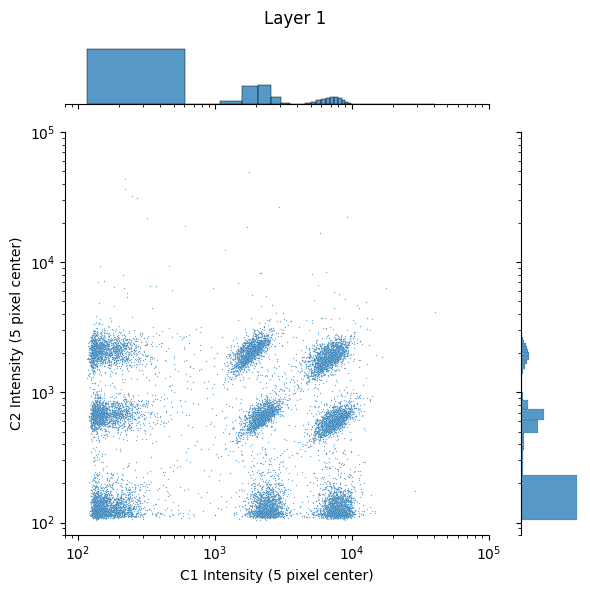

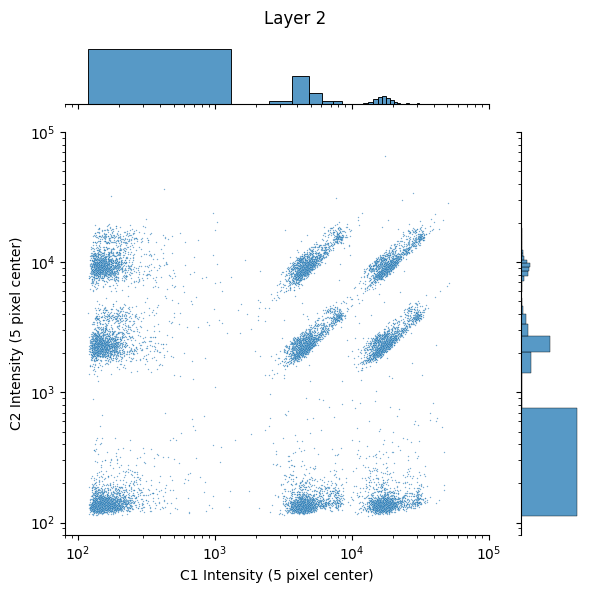

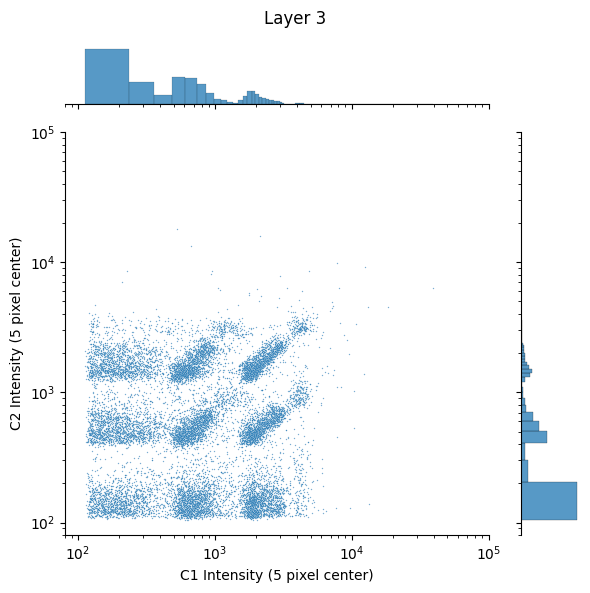

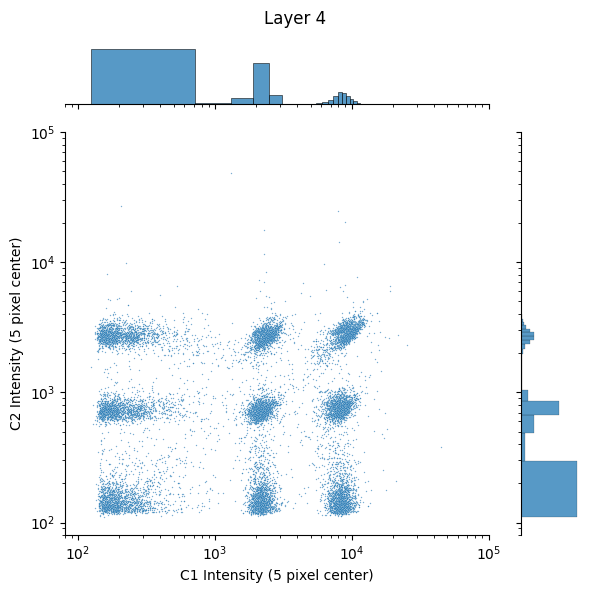

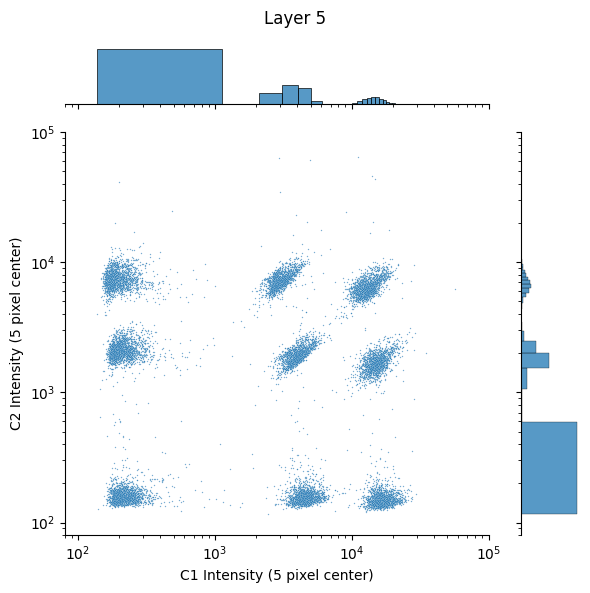

In [3]:
layer_dfs = []
for i in range(1, 6):
    df_layer = df[df["layer_id"] == f"Layer {i}"]
    layer_dfs.append(df_layer)
    df_layer.head()
    g = sns.jointplot(data=df_layer, x='c1_intensity_center_5pixel', y='c2_intensity_center_5pixel',
                      alpha=0.6, s=1)

    g.ax_joint.set_xscale('log')
    g.ax_joint.set_yscale('log')
    g.ax_marg_x.set_xscale('log')
    g.ax_marg_y.set_yscale('log')

    g.set_axis_labels('C1 Intensity (5 pixel center)',
                      'C2 Intensity (5 pixel center)')

    g.fig.suptitle(f'Layer {i}')

    g.ax_joint.set_xlim(8e1, 1e5)
    g.ax_joint.set_ylim(8e1, 1e5)

    plt.tight_layout()
    plt.show()

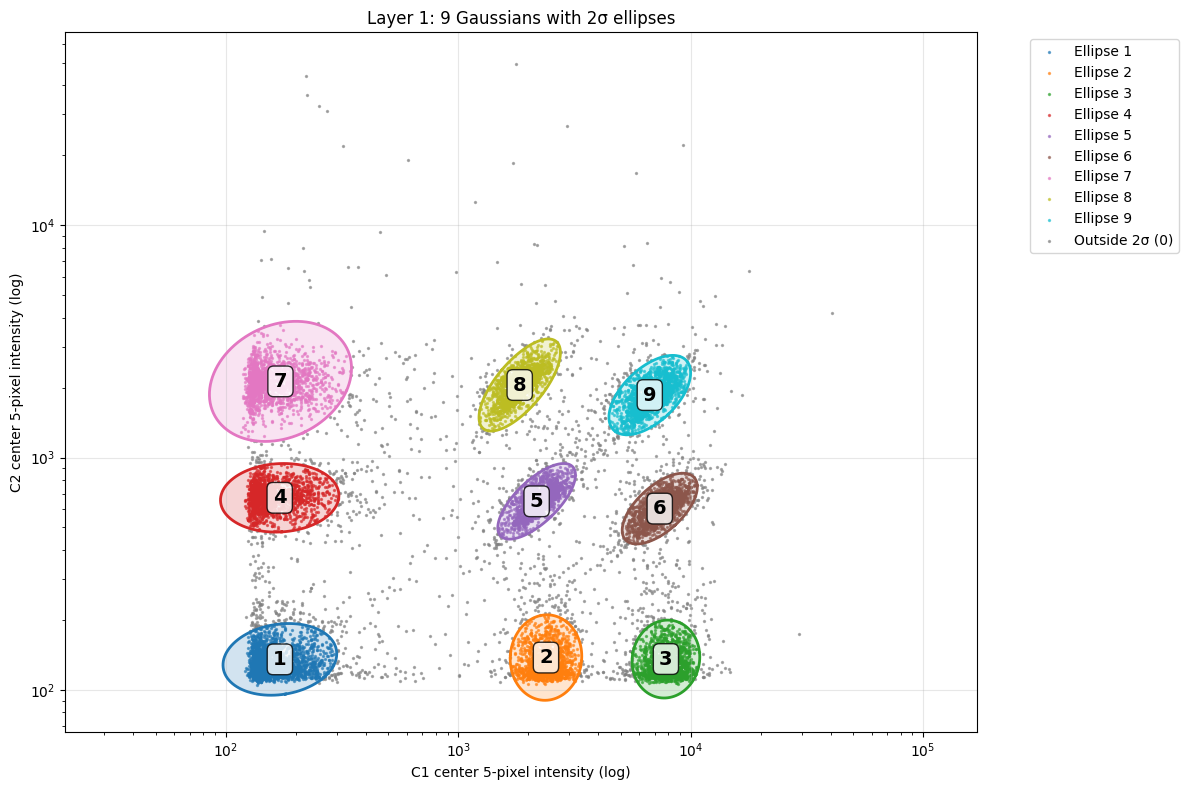

Layer 1 - Unique IDs and counts: {np.int64(0): np.int64(1698), np.int64(1): np.int64(2055), np.int64(2): np.int64(1466), np.int64(3): np.int64(1514), np.int64(4): np.int64(1525), np.int64(5): np.int64(1496), np.int64(6): np.int64(1512), np.int64(7): np.int64(1550), np.int64(8): np.int64(1664), np.int64(9): np.int64(1694)}


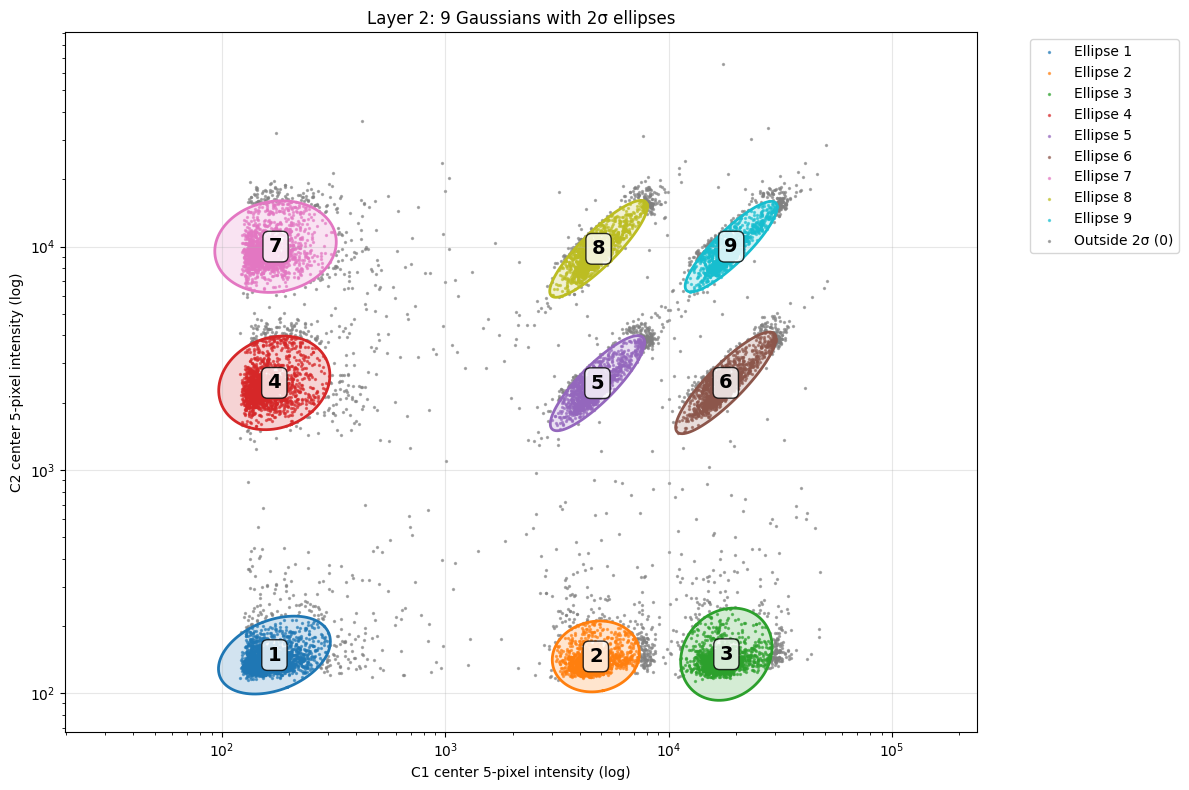

Layer 2 - Unique IDs and counts: {np.int64(0): np.int64(2045), np.int64(1): np.int64(2011), np.int64(2): np.int64(1522), np.int64(3): np.int64(1557), np.int64(4): np.int64(1598), np.int64(5): np.int64(1525), np.int64(6): np.int64(1544), np.int64(7): np.int64(1498), np.int64(8): np.int64(1604), np.int64(9): np.int64(1270)}


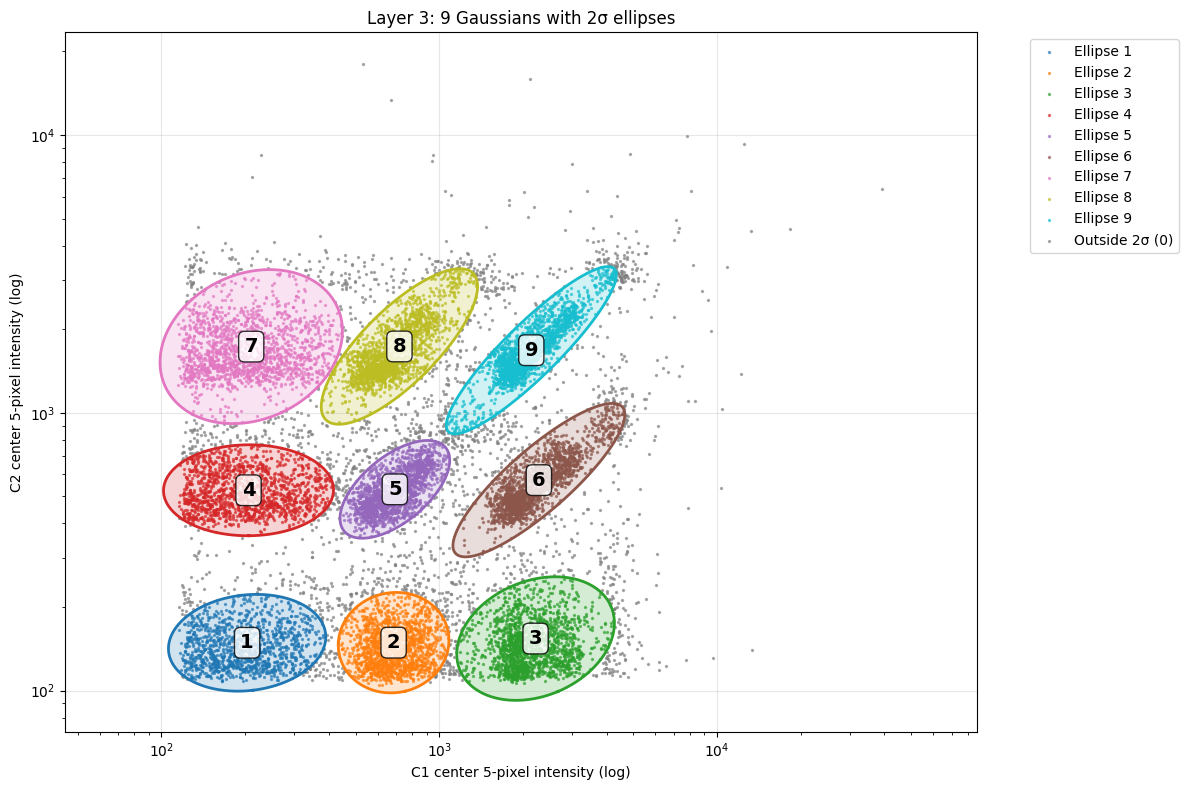

Layer 3 - Unique IDs and counts: {np.int64(0): np.int64(2091), np.int64(1): np.int64(1197), np.int64(2): np.int64(1460), np.int64(3): np.int64(1680), np.int64(4): np.int64(1384), np.int64(5): np.int64(1576), np.int64(6): np.int64(1705), np.int64(7): np.int64(1526), np.int64(8): np.int64(1725), np.int64(9): np.int64(1830)}


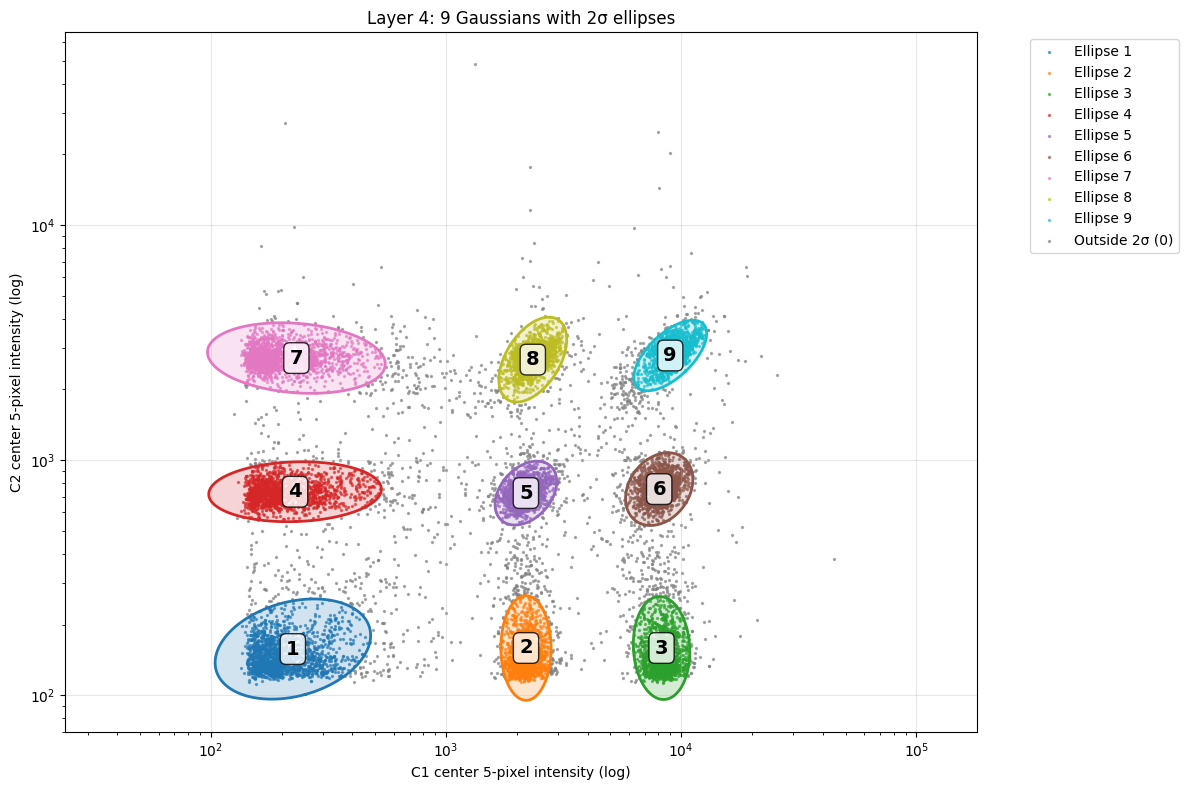

Layer 4 - Unique IDs and counts: {np.int64(0): np.int64(1839), np.int64(1): np.int64(1575), np.int64(2): np.int64(1462), np.int64(3): np.int64(1521), np.int64(4): np.int64(1483), np.int64(5): np.int64(1565), np.int64(6): np.int64(1667), np.int64(7): np.int64(1556), np.int64(8): np.int64(1737), np.int64(9): np.int64(1769)}


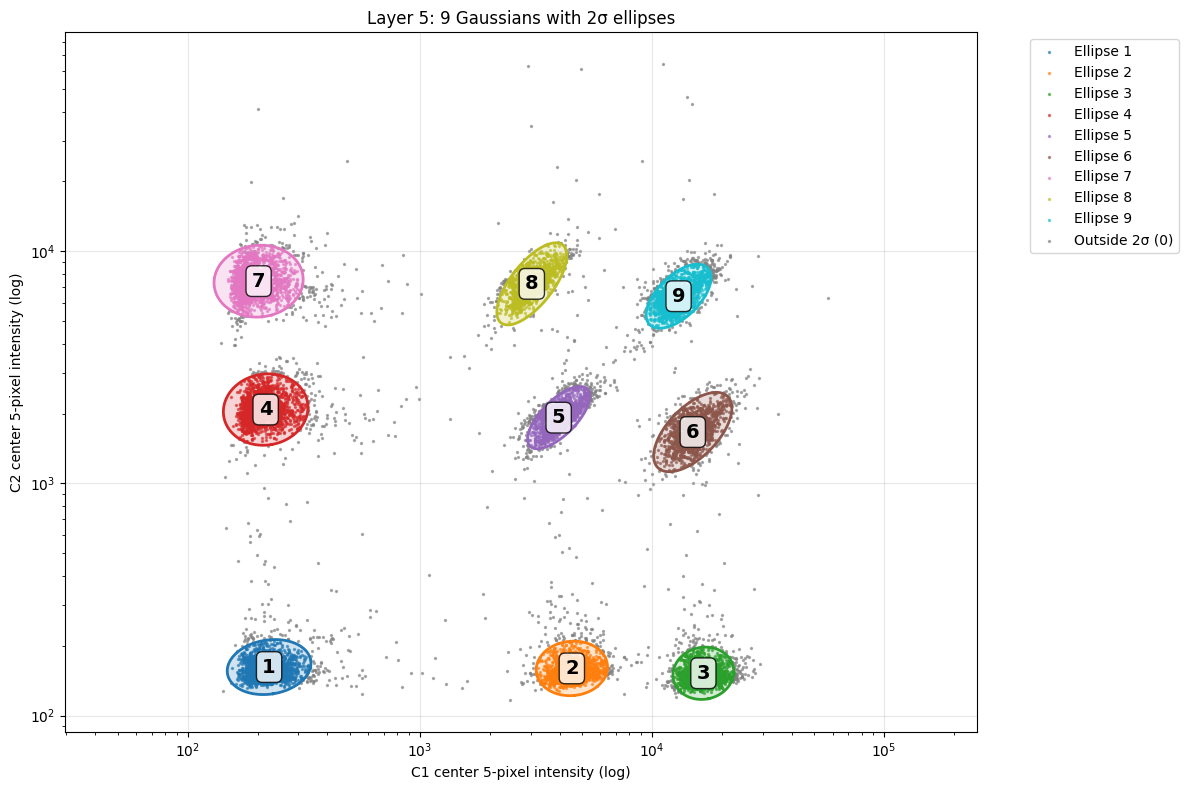

Layer 5 - Unique IDs and counts: {np.int64(0): np.int64(1557), np.int64(1): np.int64(1839), np.int64(2): np.int64(1652), np.int64(3): np.int64(1557), np.int64(4): np.int64(1780), np.int64(5): np.int64(1537), np.int64(6): np.int64(1433), np.int64(7): np.int64(1580), np.int64(8): np.int64(1646), np.int64(9): np.int64(1593)}


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def fit_gaussians(x_data, y_data, n_components=9):
    data = np.column_stack([x_data, y_data])
    gmm = GaussianMixture(n_components=n_components, random_state=1235)
    gmm.fit(data)
    return gmm


def assign_ellipse_ids(gmm):
    """
    789
    456  
    123
    """
    means = gmm.means_
    x_sorted_indices = np.argsort(means[:, 0])
    y_sorted_indices = np.argsort(means[:, 1])
    x_orders = np.empty_like(x_sorted_indices)
    y_orders = np.empty_like(y_sorted_indices)
    x_orders[x_sorted_indices] = np.arange(len(means))
    y_orders[y_sorted_indices] = np.arange(len(means))

    x_grid = x_orders // 3
    y_grid = y_orders // 3
    return y_grid * 3 + x_grid + 1


def classify_points_to_ellipses(x_data, y_data, gmm, ellipse_ids, n_sigma=2):
    data = np.column_stack([x_data, y_data])

    # GMMコンポーネント順の確率を取得
    probabilities_gmm_order = gmm.predict_proba(data)
    
    # ellipse_id順に並び替えた確率配列を作成
    probabilities_ellipse_order = np.zeros_like(probabilities_gmm_order)
    for k in range(1, 10):
        gmm_component_idx = np.where(ellipse_ids == k)[0][0]
        probabilities_ellipse_order[:, k-1] = probabilities_gmm_order[:, gmm_component_idx]
    
    best_gaussian_indices = np.argmax(probabilities_gmm_order, axis=1)
    point_ellipse_ids = ellipse_ids[best_gaussian_indices]

    within_n_sigma = np.zeros(len(data), dtype=bool)
    mahal_threshold = n_sigma ** 2

    for i in range(len(gmm.means_)):
        mean = gmm.means_[i]
        cov = gmm.covariances_[i]

        diff = data - mean
        inv_cov = np.linalg.inv(cov)
        mahal_dist_sq = np.sum(diff @ inv_cov * diff, axis=1)

        within_ellipse = mahal_dist_sq <= mahal_threshold
        assigned_to_this_gaussian = (best_gaussian_indices == i)
        within_n_sigma |= (assigned_to_this_gaussian & within_ellipse)

    # n_sigma範囲外を0にする
    point_ellipse_ids[~within_n_sigma] = 0

    return point_ellipse_ids, probabilities_ellipse_order


def plot_gaussians_with_ellipses(x_data, y_data, gmm, ellipse_ids, point_ellipse_ids, fig_title, n_sigma=2):
    plt.figure(figsize=(12, 8))

    ellipse_colors = {
        0: '#808080',  # Gray for outside n_sigma
        1: '#1f77b4',  # Blue
        2: '#ff7f0e',  # Orange
        3: '#2ca02c',  # Green
        4: '#d62728',  # Red
        5: '#9467bd',  # Purple
        6: '#8c564b',  # Brown
        7: '#e377c2',  # Pink
        8: '#bcbd22',  # Olive
        9: '#17becf'   # Cyan
    }

    for ellipse_id in np.unique(point_ellipse_ids):
        mask = point_ellipse_ids == ellipse_id
        x = 10 ** x_data[mask]
        y = 10 ** y_data[mask]
        if ellipse_id != 0:
            label = f'Ellipse {ellipse_id}'
        else:
            label = f'Outside {n_sigma}σ (0)'
        plt.scatter(x, y, alpha=0.6, s=2,
                    color=ellipse_colors[ellipse_id], label=label)

    for mean, cov, ellipse_id in zip(gmm.means_, gmm.covariances_, ellipse_ids):
        theta = np.linspace(0, 2*np.pi, 100)
        eigenvals, eigenvecs = np.linalg.eigh(cov)

        # n_sigma楕円上の点
        ellipse_points = np.column_stack([
            n_sigma * np.sqrt(eigenvals[0]) * np.cos(theta),
            n_sigma * np.sqrt(eigenvals[1]) * np.sin(theta)
        ])

        rotated_points = ellipse_points @ eigenvecs.T + mean

        x_plot = 10**rotated_points[:, 0]
        y_plot = 10**rotated_points[:, 1]

        plt.plot(x_plot, y_plot, color=ellipse_colors[ellipse_id], linewidth=2)
        plt.fill(x_plot, y_plot, color=ellipse_colors[ellipse_id], alpha=0.2)

        plt.text(10**mean[0], 10**mean[1], str(ellipse_id), fontsize=14, fontweight='bold',
                 ha='center', va='center', color='black',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    plt.xlabel('C1 center 5-pixel intensity (log)')
    plt.ylabel('C2 center 5-pixel intensity (log)')
    plt.xscale('log')
    plt.yscale('log')
    plt.title(
        f'{fig_title}: {len(gmm.means_)} Gaussians with {n_sigma}σ ellipses')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    handles, labels = plt.gca().get_legend_handles_labels()
    sorted_indices = np.argsort(labels)
    sorted_handles = [handles[idx] for idx in sorted_indices]
    sorted_labels = [labels[idx] for idx in sorted_indices]
    plt.legend(sorted_handles, sorted_labels,
               bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"../output/figures/0529_{fig_title}_251109.svg", dpi=300)
    plt.show()


df_list = []
for i in range(1, 6):
    layer_mask = df["layer_id"] == f"Layer {i}"
    df_layer = df[layer_mask]
    
    x_data = np.log10(df_layer['c1_intensity_center_5pixel'].values + 1)
    y_data = np.log10(df_layer['c2_intensity_center_5pixel'].values + 1)

    gmm = fit_gaussians(x_data, y_data, n_components=9)
    
    # GMMのピークに左下から右上の順に1-9を割り当てる
    ellipse_ids = assign_ellipse_ids(gmm)
    
    # 全ての点を0-9に分類する（確率はellipse_id順で返される）
    point_ellipse_ids, probabilities_ellipse_order = classify_points_to_ellipses(
        x_data, y_data, gmm, ellipse_ids, n_sigma=2
    )

    # ellipse_idを格納（layer_maskを使って正しいインデックスに代入）
    df.loc[layer_mask, f'ellipse_id_layer_{i}'] = point_ellipse_ids
    
    # 確率をellipse_id順に格納
    for k in range(1, 10):
        df.loc[layer_mask, f'probabilities_{k}'] = probabilities_ellipse_order[:, k-1]

    plot_gaussians_with_ellipses(
        x_data, y_data, gmm, ellipse_ids, point_ellipse_ids, f"Layer {i}", n_sigma=2)

    unique_ids, counts = np.unique(point_ellipse_ids, return_counts=True)
    print(f"Layer {i} - Unique IDs and counts: {dict(zip(unique_ids, counts))}")
    
    df_list.append(df[layer_mask].copy())

df_concat = pd.concat(df_list, ignore_index=True)

In [5]:
concat_index = df_concat[['field_name', 'bar_id',
                          'layer_id']].drop_duplicates().index

In [8]:
df_concat_cp = df_concat.loc[concat_index].reset_index(drop=True)
df_concat_cp.to_csv("../output/0529.csv", index=False)

In [9]:
df_concat_cp.loc[:, ["field_name", "layer_id"]+[f"probabilities_{i}" for i in range(1, 10)]+ [f"ellipse_id_layer_{i}" for i in range(1, 6)]]

,field_name,layer_id,probabilities_1,probabilities_2,probabilities_3,probabilities_4,probabilities_5,probabilities_6,probabilities_7,probabilities_8,probabilities_9,ellipse_id_layer_1,ellipse_id_layer_2,ellipse_id_layer_3,ellipse_id_layer_4,ellipse_id_layer_5
0,A - 1_fld-87,Layer 1,3.674432e-58,8.723668e-28,7.333587e-20,5.025913e-40,1.774605e-17,9.999998e-01,6.925124e-35,2.857516e-51,1.537256e-07,0.0,NaN,NaN,NaN,NaN
1,A - 1_fld-87,Layer 1,9.926148e-48,5.112559e-19,1.611350e-13,5.454178e-37,3.065884e-19,1.000000e+00,7.227630e-36,5.655998e-56,1.772664e-12,6.0,NaN,NaN,NaN,NaN
2,A - 1_fld-87,Layer 1,1.137594e-43,1.565747e-15,1.118549e-10,2.648808e-36,7.249531e-21,1.000000e+00,2.476851e-36,3.391836e-59,6.979729e-15,6.0,NaN,NaN,NaN,NaN
3,A - 1_fld-87,Layer 1,1.234428e-23,7.113674e-62,1.551021e-131,9.936856e-01,2.535937e-79,4.207523e-152,6.314406e-03,1.897822e-34,6.030088e-78,4.0,NaN,NaN,NaN,NaN
4,A - 1_fld-87,Layer 1,3.899013e-76,3.408709e-42,2.285321e-40,1.468480e-43,1.335553e-10,1.196882e-13,1.248570e-28,3.234541e-25,1.000000e+00,9.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80865,A - 2_fld-122,Layer 5,1.325690e-179,2.830997e-264,0.000000e+00,1.041769e-12,3.496446e-303,3.035338e-273,1.000000e+00,1.626654e-114,3.485106e-247,NaN,NaN,NaN,NaN,7.0
80866,A - 2_fld-122,Layer 5,9.000441e-175,4.316018e-167,1.611109e-223,5.471405e-40,5.092227e-38,4.518643e-67,7.019753e-32,1.000000e+00,8.175695e-31,NaN,NaN,NaN,NaN,8.0
80867,A - 2_fld-122,Layer 5,7.326768e-132,1.291382e-68,7.774099e-69,3.325515e-93,5.315615e-42,1.000000e+00,3.644751e-106,2.593307e-103,4.502647e-32,NaN,NaN,NaN,NaN,6.0
80868,A - 2_fld-122,Layer 5,1.000000e+00,5.074723e-69,5.448116e-190,1.025978e-47,1.069274e-86,5.317842e-110,9.702844e-104,1.670678e-81,4.129975e-171,NaN,NaN,NaN,NaN,1.0
